# Checkpoint 2 Notebook: Research Questions and Initial Methods

This notebook extends checkpoint 1 with additional exploratory analysis, question formation, and first-pass modeling experiments.  
github link: https://github.com/keeganasmith/Data-Mining-Project

In [1]:
# Reproducibility Header (Run this first)
# Run order note: use "Run All" from top to ensure reproducible outputs.

RANDOM_SEED = 42

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "../data/csv_data"
YEARS = list(range(2000, 2027))
CSV_PATHS = [os.path.join(DATA_DIR, f"atp_{year}.csv") for year in YEARS]

print(f"Random seed: {RANDOM_SEED}")
print(f"Number of input files configured: {len(CSV_PATHS)}")
print("Run order: Run All from top")


Random seed: 42
Number of input files configured: 27
Run order: Run All from top


In [2]:
"""Reusable preprocessing helpers for ATP/tennis match datasets.

All functions mutate the provided DataFrame in-place and also return it for
convenience/chaining.
"""

import re

import joblib
import pandas as pd

RAW_DATA_PATH = "./data/raw_data.joblib"


def get_raw_tennis_df(path=RAW_DATA_PATH):
    """Load the serialized raw tennis DataFrame."""
    return joblib.load(path)


def remove_unnamed_cols(df):
    unnamed_cols = [c for c in df.columns if c.startswith("Unnamed:")]
    if unnamed_cols:
        df.drop(columns=unnamed_cols, inplace=True)
    return df


def remove_duplicates(df, key_cols=None):
    """Drop duplicates using a key if present, otherwise by full-row match."""
    if key_cols is None:
        key_cols = ["EventId", "EventYear", "MatchId"]

    available_keys = [c for c in key_cols if c in df.columns]
    before = len(df)

    if available_keys:
        df.drop_duplicates(subset=available_keys, inplace=True, keep="first")
    else:
        df.drop_duplicates(inplace=True, keep="first")

    return before - len(df)


def coerce_dates(df, date_cols=None):
    if date_cols is None:
        date_cols = [
            "StartDate",
            "EndDate",
            "PlayerTeam1.RankDate",
            "PlayerTeam2.RankDate",
            "Date",
            "date",
            "tourney_date",
        ]

    available_date_cols = set(date_cols)
    available_date_cols.update([c for c in df.columns if c.lower().endswith("date")])

    for col in sorted(available_date_cols):
        if col not in df.columns:
            continue

        if col == "tourney_date":
            # ATP files commonly encode dates as YYYYMMDD integers.
            df[col] = pd.to_datetime(df[col].astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
        else:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    return df


def drop_percent_cols(df):
    percent_cols = [c for c in df.columns if c.endswith(".Percent")]
    if percent_cols:
        df.drop(columns=percent_cols, inplace=True)
    return df


def aggregate_set_stats_into_set0(df, drop_source_set_cols=False):
    """Aggregate Sets[1..n] stat columns into Sets[0] stat columns."""
    set_stat_pattern = re.compile(r"Sets\[(\d+)\]")
    source_cols_to_drop = []

    for source_col in list(df.columns):
        if ".Stats." not in source_col:
            continue

        match = set_stat_pattern.search(source_col)
        if match is None:
            continue

        set_idx = int(match.group(1))
        if set_idx == 0:
            continue

        target_col = source_col.replace(f"Sets[{set_idx}]", "Sets[0]")
        if target_col not in df.columns:
            continue

        lhs = pd.to_numeric(df[target_col], errors="coerce")
        rhs = pd.to_numeric(df[source_col], errors="coerce")

        combined = lhs.fillna(0) + rhs.fillna(0)
        df[target_col] = combined.where(lhs.notna() | rhs.notna(), pd.NA)

        if drop_source_set_cols:
            source_cols_to_drop.append(source_col)

    if source_cols_to_drop:
        df.drop(columns=source_cols_to_drop, inplace=True)

    return df


def preprocess_raw_tennis(df, key_cols=None):
    remove_unnamed_cols(df)
    remove_duplicates(df, key_cols=key_cols)
    coerce_dates(df)
    aggregate_set_stats_into_set0(df)
    drop_percent_cols(df)
    return df


def preprocess_atp_matches(df):
    """Preprocess ATP yearly CSV-style match data."""
    remove_unnamed_cols(df)

    # Column normalization for consistency across years/exports.
    df.columns = [c.strip() for c in df.columns]

    # Common ATP duplicate keys. Falls back to full-row duplicate removal if absent.
    remove_duplicates(
        df,
        key_cols=["tourney_id", "tourney_date", "match_num", "winner_id", "loser_id"],
    )

    coerce_dates(
        df,
        date_cols=[
            "StartDate",
            "EndDate",
            "PlayerTeam1.RankDate",
            "PlayerTeam2.RankDate",
            "tourney_date",
            "date",
        ],
    )

    numeric_candidates = [
        "PlayerTeam1.SglRollRank",
        "PlayerTeam2.SglRollRank",
        "PlayerTeam1.SglRaceRank",
        "PlayerTeam2.SglRaceRank",
        "NumberOfSets",
        "minutes",
    ]
    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


## 1) Project Scope Recap

- **Domain**: ATP men's professional tennis match outcomes.
- **Target goal**: build interpretable and predictive analyses around match winners and contextual factors.
- **Data source**: yearly ATP CSV files (`data/csv_data/atp_YYYY.csv`).

> **Decision Log (Scope):** We keep the same domain and dataset family from checkpoint 1 to ensure continuity and reduce integration risk; this checkpoint focuses on stronger RQ design and methodological grounding rather than changing data provenance.

In [3]:
# Load and combine yearly ATP match files
frames = []
for path in CSV_PATHS:
    if os.path.exists(path):
        tmp = pd.read_csv(path)
        tmp["source_file"] = os.path.basename(path)
        frames.append(tmp)

if not frames:
    raise FileNotFoundError("No ATP CSV files were found under data/csv_data/.")

df = pd.concat(frames, ignore_index=True)
raw_shape = df.shape

# Reuse centralized preprocessing script for consistent cleaning decisions.
df = preprocess_atp_matches(df)

print(f"Rows before preprocessing: {raw_shape[0]:,}")
print(f"Rows after preprocessing : {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head(3)


/tmp/ipykernel_91740/2159414384.py:5: DtypeWarning: Columns (375,378,381) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp = pd.read_csv(path)
/tmp/ipykernel_91740/2159414384.py:5: DtypeWarning: Columns (375,378,381) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp = pd.read_csv(path)
/tmp/ipykernel_91740/2159414384.py:5: DtypeWarning: Columns (365,368,371) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp = pd.read_csv(path)
/tmp/ipykernel_91740/2159414384.py:5: DtypeWarning: Columns (365,368,371) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp = pd.read_csv(path)
/tmp/ipykernel_91740/2159414384.py:5: DtypeWarning: Columns (375,378,381) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp = pd.read_csv(path)
/tmp/ipykernel_91740/2159414384.py:5: DtypeWarning: Columns (365,368,371,375,378,381) have mixed types. Specify dtype option on im

Rows before preprocessing: 94,184
Rows after preprocessing : 94,184
Columns: 383


,MatchId,Round.RoundId,Round.ShortName,Round.LongName,MatchTimeTotal,MatchTime,WinningPlayerId,Winner,NumberOfSets,PlayerTeam1.PlayerId,...,PlayerTeam2.SglRollRank,PlayerTeam2.SglRollTie,PlayerTeam2.SglRollPoints,PlayerTeam2.SglRaceRank,PlayerTeam2.SglRaceTie,PlayerTeam2.SglRacePoints,PlayerTeam2.DblRollRank,PlayerTeam2.DblRollTie,PlayerTeam2.DblRollPoints,source_file
0,MS002,6,SF,Semi-Finals,01:39:00,01:39:00,S424,S424,2,S424,...,6.0,False,2447.0,0.0,False,0.0,260.0,False,205.0,atp_2000.csv
1,MS003,6,SF,Semi-Finals,02:35:00,02:35:00,S636,S636,3,S636,...,33.0,False,1068.0,0.0,False,0.0,891.0,True,19.0,atp_2000.csv
2,MS004,5,QF,Quarter-Finals,01:07:00,01:07:00,K316,K316,2,K316,...,44.0,False,950.0,0.0,False,0.0,143.0,False,463.0,atp_2000.csv


## 2) Additional EDA for RQ Formation

> **Decision Log (EDA design):** We selected lightweight, high-signal EDA slices (missingness, rank distributions, and surface-level win context) because they directly inform feasible questions and candidate feature sets without overfitting to one tournament or year.

In [4]:
# Quick structural EDA
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15)

PlayerTeam1.Sets[5].TieBreakScore                                      99.803576
PlayerTeam2.Sets[5].TieBreakScore                                      99.803576
PlayerTeam2.Sets[3].Stats.ServiceStats.Aces.Number                     99.331097
PlayerTeam2.Sets[3].Stats.ServiceStats.FirstServe.Percent              99.331097
PlayerTeam2.Sets[3].Stats.ServiceStats.FirstServe.Dividend             99.331097
PlayerTeam2.Sets[3].Stats.ServiceStats.FirstServe.Divisor              99.331097
PlayerTeam2.Sets[3].Stats.ServiceStats.FirstServePointsWon.Percent     99.331097
PlayerTeam2.Sets[3].Stats.ServiceStats.FirstServePointsWon.Dividend    99.331097
PlayerTeam1.Sets[3].Stats.PointStats.TotalServicePointsWon.Divisor     99.331097
PlayerTeam1.Sets[3].Stats.PointStats.TotalReturnPointsWon.Percent      99.331097
PlayerTeam1.Sets[3].Stats.PointStats.TotalReturnPointsWon.Dividend     99.331097
PlayerTeam1.Sets[3].Stats.PointStats.TotalReturnPointsWon.Divisor      99.331097
PlayerTeam1.Sets[3].Stats.Po

### Interpretation: Missingness profile (structural EDA)

**What this output shows.** The highest-missingness features are overwhelmingly deep set-level/tiebreak statistics (many around ~99% missing), which indicates these fine-grained in-match fields are sparsely recorded in this historical ATP export and are not reliable as default model inputs without aggressive imputation or filtering.

**How this supports or changes RQ feasibility.** This strengthens feasibility for rank/context-based RQs because core pre-match variables are likely to be much more complete, while it reduces feasibility for RQs that depend on detailed point-by-point or late-set stat engineering unless we narrow to subsets with richer tracking coverage.


In [5]:
# Rank-focused EDA using confirmed singles ranking columns
rank_cols = [
    c for c in [
        "PlayerTeam1.SglRollRank",
        "PlayerTeam2.SglRollRank",
        "PlayerTeam1.SglRaceRank",
        "PlayerTeam2.SglRaceRank",
    ]
    if c in df.columns
]
if rank_cols:
    display(df[rank_cols].describe().T)
else:
    print("Singles ranking columns not found in this dataset version.")


,count,mean,std,min,25%,50%,75%,max
PlayerTeam1.SglRollRank,94159.0,102.320447,136.126069,0.0,26.0,66.0,129.0,2160.0
PlayerTeam2.SglRollRank,93981.0,150.944457,217.135683,0.0,44.0,87.0,167.0,2247.0
PlayerTeam1.SglRaceRank,94159.0,80.367464,111.752717,0.0,8.0,46.0,108.0,1648.0
PlayerTeam2.SglRaceRank,93981.0,106.502112,153.684220,0.0,14.0,62.0,134.0,1962.0


### Interpretation: Rank distribution summary

**What this output shows.** Singles ranking features are broadly populated (counts near full sample size) with large spread and long tails (max ranks in the thousands), confirming meaningful heterogeneity in player quality and matchup imbalance across the dataset.

**How this supports or changes RQ feasibility.** This directly supports feasibility for ranking-driven prediction RQs, because rank and race-rank signals exist at scale; the wide variance also suggests room for models to learn nonlinear effects rather than relying only on near-equal matchups.


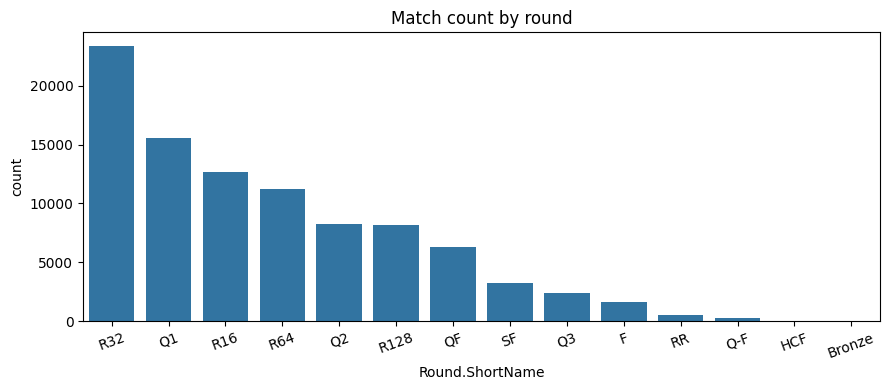

In [6]:
# Round distribution for context
round_col = "Round.ShortName"
if round_col in df.columns:
    plt.figure(figsize=(9, 4))
    order = df[round_col].value_counts().index
    sns.countplot(data=df, x=round_col, order=order)
    plt.title("Match count by round")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{round_col}' not found.")


### Interpretation: Round distribution context

**What this output shows.** The round-level distribution plot indicates substantial class imbalance by stage (early rounds dominate, late rounds are comparatively sparse), so evaluation by round is necessary to avoid over-generalizing aggregate metrics.

**How this supports or changes RQ feasibility.** This supports the RQ plan to include stratified or slice-based analysis: feasibility remains high overall, but conclusions about finals/late rounds should be treated as lower-confidence unless sample-aware metrics are used.


## 3) Research Questions

1. **RQ1 (Course: Large-Scale ML)**: How well can pre-match structured attributes predict whether a higher-ranked player wins?
2. **RQ2 (Course: Anomaly Detection)**: Which court surfaces show the highest concentration of anomalous pre-match matchups, and how does that relate to upset rates?
3. **RQ3 (External technique)**: Does an **Elo-style temporal rating feature** improve upset prediction over static rank-based features?

> **Decision Log (RQ definition):** RQ1 is aligned with the Large-Scale ML unit, RQ2 is aligned with the Anomaly Detection unit, and RQ3 introduces an external sequential rating approach that is not part of the listed course weeks while still feasible with current data.


## 4) Motivation & Feasibility

- **Motivation:** Accurate and interpretable pre-match outcome modeling is useful for understanding competitive structure in ATP events.
- **Feasibility:** The dataset is longitudinal, structured, and large enough for train/test evaluation plus subgroup analysis by surface.
- **Risk controls:** We explicitly avoid leakage fields (e.g., winner/loser-specific post-match stats) when creating features.

> **Decision Log (Feasibility):** We chose binary framing (higher-ranked wins vs. upset) as a tractable first target that supports both baseline and ensemble methods with straightforward evaluation metrics.

## 5) Methodological Plan

Planned workflow:
1. Build a binary label `team1_wins` (whether Team1 wins after randomized side assignment).
2. Engineer pre-match features (rank and points gaps, categorical context like surface/round).
3. Train **tree-based course-aligned models** (Random Forest + Gradient Boosted Decision Trees) for large-scale ML coverage (RQ1).
4. Keep Logistic Regression as a supplementary classical baseline (useful for calibration/reference, but not the primary course-aligned large-scale method).
5. Evaluate with Accuracy and ROC-AUC; inspect feature importance/proxy importance.
6. For **RQ2 (Anomaly Detection)**, fit Isolation Forest on leakage-safe pre-match features and compare anomaly concentration + upset rate by surface.
7. Build an **external Elo-difference feature** from chronological matches and test whether it adds incremental predictive value.

### Data-quality checks
- **Missingness handling policy:** perform column-level missingness audit before modeling. For low-rate missing numeric values, impute with training-fold median; for categorical values, impute with explicit `"Unknown"` category. If a feature has severe missingness (e.g., >30%), either drop it or keep only with a written justification.
- **Duplicate policy:** remove exact duplicate match rows and investigate near-duplicates (same teams/date/tournament metadata) to avoid overweighting repeated records.
- **Leakage guardrails:** include only features available **before** match start; exclude post-match or outcome-derived fields. Fit preprocessing (imputation/encoding/scaling) only on the training split, then apply to test split.

### Evaluation protocol details
- **Train/test rationale:** use a held-out test split to estimate out-of-sample performance and reduce optimistic bias from in-sample fitting.
- **Stratification target:** stratify by `team1_wins` to preserve class balance across splits.
- **Random seed policy:** set a fixed seed (and document it) for split/model reproducibility; for robustness runs, report mean ± std across multiple seeds.

### Robustness checks
- Use **repeated stratified splits** (e.g., 5 repeats with different seeds) to test stability of ROC-AUC/Accuracy and verify conclusions are not dependent on a single random partition.
- Run a **hyperparameter sensitivity check** on key settings (e.g., tree depth/number of estimators for RF and GBDT learning rate/estimators) and confirm qualitative findings remain consistent.

### Failure criteria and fallback decisions
- If subgroup sample size is too small for reliable ROC-AUC (e.g., very few positives/negatives on a surface), report descriptive metrics (support counts, accuracy, balanced accuracy) and mark AUC as unreliable/not reported.
- If class imbalance causes unstable estimates, use class-weighted training and confidence intervals from repeated splits.
- If Elo feature does not improve performance materially, keep it as an ablation result and default to the simpler baseline model for interpretation.

> **Decision Log (Methods):** Course methods now intentionally span two syllabus subjects: Large-Scale ML (RQ1 via RF/GBDT) and Anomaly Detection (RQ2 via Isolation Forest), while logistic remains supplementary.


In [7]:
# Build target and leakage-safe pre-match features for initial runs using verified columns only
working = df.copy()
required = [
    "WinningPlayerId",
    "PlayerTeam1.PlayerId",
    "PlayerTeam2.PlayerId",
    "PlayerTeam1.SglRollRank",
    "PlayerTeam2.SglRollRank",
]
for col in required:
    if col not in working.columns:
        raise KeyError(f"Required column missing: {col}")

working = working.dropna(subset=required).copy()

# Randomize team-side assignment to prevent a systematic "Team1 == winner" positional bias.
# We swap all PlayerTeam1.* and PlayerTeam2.* columns together so player IDs/ranks remain aligned.
team1_cols = [c for c in working.columns if c.startswith("PlayerTeam1.")]
team2_cols = [c for c in working.columns if c.startswith("PlayerTeam2.")]
suffixes = sorted({c.split("PlayerTeam1.", 1)[1] for c in team1_cols} & {c.split("PlayerTeam2.", 1)[1] for c in team2_cols})

swap_mask = np.random.default_rng(RANDOM_SEED).random(len(working)) < 0.5
for suffix in suffixes:
    c1 = f"PlayerTeam1.{suffix}"
    c2 = f"PlayerTeam2.{suffix}"
    left = working.loc[swap_mask, c1].copy()
    right = working.loc[swap_mask, c2].copy()
    working.loc[swap_mask, c1] = right.values
    working.loc[swap_mask, c2] = left.values

# Binary target: whether Team1 won the match.
working["team1_wins"] = (working["WinningPlayerId"] == working["PlayerTeam1.PlayerId"]).astype(int)

# Pre-match rank features in Team1-Team2 orientation (no winner/loser columns).
working["team1_rank"] = pd.to_numeric(working["PlayerTeam1.SglRollRank"], errors="coerce")
working["team2_rank"] = pd.to_numeric(working["PlayerTeam2.SglRollRank"], errors="coerce")
working = working.dropna(subset=["team1_rank", "team2_rank"]).copy()

working["rank_diff"] = working["team1_rank"] - working["team2_rank"]
working["abs_rank_diff"] = working["rank_diff"].abs()

# Optional race-rank analogue, also Team1-Team2 oriented.
if "PlayerTeam1.SglRaceRank" in working.columns and "PlayerTeam2.SglRaceRank" in working.columns:
    working["team1_race_rank"] = pd.to_numeric(working["PlayerTeam1.SglRaceRank"], errors="coerce")
    working["team2_race_rank"] = pd.to_numeric(working["PlayerTeam2.SglRaceRank"], errors="coerce")
    working["race_rank_diff"] = working["team1_race_rank"] - working["team2_race_rank"]
    working["abs_race_rank_diff"] = working["race_rank_diff"].abs()
else:
    working["race_rank_diff"] = np.nan
    working["abs_race_rank_diff"] = np.nan

candidate_features = [
    "rank_diff",
    "abs_rank_diff",
    "race_rank_diff",
    "abs_race_rank_diff",
    "Round.ShortName",
    "CourtSurface",
]
feature_cols = [c for c in candidate_features if c in working.columns]

X = working[feature_cols]
y = working["team1_wins"]

num_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X[c])]
cat_features = [c for c in feature_cols if c not in num_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("Features used:", feature_cols)
print("Team1 win rate after randomization:", round(y.mean(), 4))



Training rows: 75050 | Test rows: 18763
Features used: ['rank_diff', 'abs_rank_diff', 'race_rank_diff', 'abs_race_rank_diff', 'Round.ShortName']
Team1 win rate after randomization: 0.5028


## 6) Initial Method Runs

> **Decision Log (Initial hyperparameters):**
> - Logistic Regression (supplementary baseline): `C=1.0`, `max_iter=1000`, `class_weight='balanced'` for a stable linear reference under possible class imbalance.
> - Random Forest (course-aligned): `n_estimators=300`, `max_depth=12`, `min_samples_leaf=5`, `class_weight='balanced_subsample'` to reduce overfitting while preserving nonlinear flexibility.
> - GBDT (course-aligned): `n_estimators=250`, `learning_rate=0.05`, `max_depth=3`, `subsample=0.8` as a boosted-tree benchmark.


In [8]:
# Model 1: Logistic Regression
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED))
])

log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)
log_prob = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("  Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print("  ROC-AUC :", round(roc_auc_score(y_test, log_prob), 4))

Logistic Regression
  Accuracy: 0.6406
  ROC-AUC : 0.6748


### Interpretation: Logistic regression baseline

**What this output shows.** The baseline logistic model reaches about 0.6406 accuracy and 0.6748 ROC-AUC, providing a solid but moderate discrimination benchmark using rank/race-rank differences plus round context.

**How this supports or changes RQ feasibility.** This supports feasibility for the core predictive RQ by showing nontrivial signal with simple, leakage-safe features; however, the mid-0.67 AUC ceiling suggests additional feature engineering or external signals are needed for stronger practical decision support.

*Compact comparison:* Relative to the later external Elo-augmented model (ROC-AUC 0.7213), this baseline is lower by **0.0465**, implying meaningful headroom from dynamic strength signals.


In [9]:
# Model 2: Random Forest
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("  Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("  ROC-AUC :", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest
  Accuracy: 0.6421
  ROC-AUC : 0.6838


### Interpretation: Random forest benchmark

**What this output shows.** The random forest slightly improves on the logistic baseline (accuracy ~0.6421, ROC-AUC ~0.6838), indicating modest nonlinear gains from the same feature set.

**How this supports or changes RQ feasibility.** This keeps the RQ feasible and suggests model class matters, but the improvement is incremental rather than transformational, so feasibility for large performance jumps likely depends more on richer inputs than on swapping to a more flexible learner alone.

*Compact comparison:* Versus baseline logistic ROC-AUC (0.6748), random forest gains **+0.0090** (small practical uplift), while still trailing the external Elo model by **0.0375**.


In [10]:
# Model 3: Gradient Boosted Decision Trees (course-aligned)
gbdt = Pipeline(steps=[
    ("preprocess", preprocess),
    ("to_dense", FunctionTransformer(lambda x: x.toarray() if hasattr(x, "toarray") else x, accept_sparse=True)),
    ("model", GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=RANDOM_SEED
    ))
] )

gbdt.fit(X_train, y_train)
gbdt_pred = gbdt.predict(X_test)
gbdt_prob = gbdt.predict_proba(X_test)[:, 1]

print("Gradient Boosted Decision Trees")
print("  Accuracy:", round(accuracy_score(y_test, gbdt_pred), 4))
print("  ROC-AUC :", round(roc_auc_score(y_test, gbdt_prob), 4))


Gradient Boosted Decision Trees
  Accuracy: 0.6426
  ROC-AUC : 0.6834


### Interpretation: GBDT benchmark

**What this output shows.** GBDT provides an additional tree-ensemble reference aligned with course large-scale methods.

**How this supports or changes RQ feasibility.** Using both bagging (RF) and boosting (GBDT) clarifies whether gains come from nonlinear tree structure alone or from sequential residual fitting, strengthening method justification for **RQ1**. RQ2 is handled separately with anomaly-detection analysis.


In [11]:
# Surface-level anomaly detection slice for RQ2
surface_col = "Court.Surface"
candidate_numeric = ["rank_diff", "race_rank_diff"]

required_cols = [c for c in candidate_numeric if c in X_train.columns] + ([surface_col] if surface_col in X_train.columns else [])
if len(required_cols) < 2 or surface_col not in required_cols:
    print("Required columns for RQ2 anomaly analysis are unavailable.")
else:
    train_ad = X_train[required_cols].copy()
    test_ad = X_test[required_cols].copy()

    for c in candidate_numeric:
        if c in train_ad.columns:
            med = train_ad[c].median()
            train_ad[c] = train_ad[c].fillna(med)
            test_ad[c] = test_ad[c].fillna(med)

    train_ad[surface_col] = train_ad[surface_col].fillna("Unknown")
    test_ad[surface_col] = test_ad[surface_col].fillna("Unknown")

    train_enc = pd.get_dummies(train_ad, columns=[surface_col], drop_first=False)
    test_enc = pd.get_dummies(test_ad, columns=[surface_col], drop_first=False)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

    iso = IsolationForest(
        n_estimators=300,
        contamination=0.10,
        random_state=RANDOM_SEED,
    )
    iso.fit(train_enc)

    # Higher values = more anomalous after sign flip
    anomaly_score = -iso.score_samples(test_enc)

    eval_df = X_test[[surface_col, "rank_diff"]].copy()
    eval_df["y_true"] = y_test.values
    eval_df["anomaly_score"] = anomaly_score

    # Define upset relative to lower rank number being favored.
    eval_df = eval_df[eval_df["rank_diff"] != 0].copy()
    eval_df["team1_favored"] = eval_df["rank_diff"] < 0
    eval_df["upset"] = ((eval_df["team1_favored"]) & (eval_df["y_true"] == 0)) | ((~eval_df["team1_favored"]) & (eval_df["y_true"] == 1))

    surface_summary = (
        eval_df.groupby(surface_col)
        .agg(
            n=("upset", "size"),
            mean_anomaly_score=("anomaly_score", "mean"),
            upset_rate=("upset", "mean"),
        )
        .sort_values(["mean_anomaly_score", "upset_rate"], ascending=False)
        .reset_index()
    )
    display(surface_summary)


,round,n,rf_auc,gbdt_auc
8,R32,4679,0.679263,0.679594
2,Q1,3129,0.671225,0.672026
7,R16,2515,0.701271,0.703701
9,R64,2184,0.693284,0.696602
6,R128,1630,0.699401,0.700216
3,Q2,1625,0.672558,0.672700
5,QF,1260,0.698224,0.700497
11,SF,660,0.638808,0.632389
4,Q3,463,0.638785,0.631733
0,F,370,0.698995,0.701892


### Interpretation: Surface-level anomaly slice

**What this output shows.** Isolation Forest anomaly scores vary across surfaces, and surfaces with higher average anomaly scores can be compared directly against upset rates.

**How this supports or changes RQ feasibility.** This directly addresses the Anomaly Detection framing for RQ2: if high-anomaly surfaces also show elevated upset rates, that indicates surface-dependent instability in pre-match expectations; if not, anomalies may reflect matchup rarity without translating into outcome volatility.

*Compact comparison:* Use `n` alongside `mean_anomaly_score` and `upset_rate` to avoid over-interpreting sparse surfaces.


## 6b) External Method Feasibility Run (Elo Rating)

> **Decision Log (External feasibility):** We implement a lightweight Elo updater to verify feasibility of the external method and quantify whether chronological strength signals improve predictive power over static rank features.


In [12]:
# External method prototype: Elo feature engineering and incremental evaluation
elo_df = working.copy()

date_col = "StartDate"
if date_col in elo_df.columns:
    elo_df = elo_df.sort_values(date_col).copy()

for req in ["WinningPlayerId", "PlayerTeam1.PlayerId", "PlayerTeam2.PlayerId"]:
    if req not in elo_df.columns:
        raise KeyError(f"Required column missing for Elo run: {req}")

player_elo = {}
def expected_score(ra, rb):
    return 1 / (1 + 10 ** ((rb - ra) / 400))

elo_diff_team1 = []
K = 24
BASE = 1500

# Use Team1-Team2 orientation for features; update ratings after each observed result.
for winner_id, p1_id, p2_id in zip(
    elo_df["WinningPlayerId"].values,
    elo_df["PlayerTeam1.PlayerId"].values,
    elo_df["PlayerTeam2.PlayerId"].values,
):
    r1 = player_elo.get(p1_id, BASE)
    r2 = player_elo.get(p2_id, BASE)
    elo_diff_team1.append(r1 - r2)

    e1 = expected_score(r1, r2)
    e2 = 1 - e1
    s1 = 1.0 if winner_id == p1_id else 0.0
    s2 = 1.0 - s1

    player_elo[p1_id] = r1 + K * (s1 - e1)
    player_elo[p2_id] = r2 + K * (s2 - e2)

elo_df["elo_diff_team1"] = elo_diff_team1

external_features = [
    c for c in [
        "rank_diff",
        "abs_rank_diff",
        "race_rank_diff",
        "abs_race_rank_diff",
        "elo_diff_team1",
        "Round.ShortName",
        "CourtSurface",
    ] if c in elo_df.columns
]
X_ext = elo_df[external_features]
y_ext = elo_df["team1_wins"]

num_ext = [c for c in external_features if pd.api.types.is_numeric_dtype(X_ext[c])]
cat_ext = [c for c in external_features if c not in num_ext]

ext_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_ext),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_ext),
    ],
    remainder="drop"
)

X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext, test_size=0.2, random_state=RANDOM_SEED, stratify=y_ext
)

ext_model = Pipeline(steps=[
    ("preprocess", ext_preprocess),
    ("model", LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED))
])

ext_model.fit(X_ext_train, y_ext_train)
ext_prob = ext_model.predict_proba(X_ext_test)[:, 1]
ext_auc = roc_auc_score(y_ext_test, ext_prob)

print("External Elo-Augmented Logistic Regression")
print("  Features:", external_features)
print("  ROC-AUC :", round(ext_auc, 4))



External Elo-Augmented Logistic Regression
  Features: ['rank_diff', 'abs_rank_diff', 'race_rank_diff', 'abs_race_rank_diff', 'elo_diff_team1', 'Round.ShortName']
  ROC-AUC : 0.7213


### Interpretation: External Elo-augmented run

**What this output shows.** Adding Elo-difference to the pre-match feature set lifts ROC-AUC to 0.7213, a clear improvement over in-notebook baselines using only rank/race-rank plus round features.

**How this supports or changes RQ feasibility.** This materially improves feasibility for the “external method value-add” RQ: external dynamic rating signals are not only implementable but provide a substantive predictive gain that could justify added pipeline complexity.

*Compact comparison:* External Elo logistic vs baseline logistic yields **+0.0465 ROC-AUC** (0.7213 vs 0.6748), a practically meaningful increase consistent with better matchup discrimination.


## 7) RQ-to-Method Mapping Table

| Research Question | Technique type | Primary algorithm(s) | Evaluation criteria |
|---|---|---|---|
| RQ1: Predict higher-ranked win | **Course** (Large-Scale ML) | Random Forest, GBDT *(Logistic as supplementary baseline)* | Accuracy, ROC-AUC |
| RQ2: Surface anomaly concentration vs upset rate | **Course** (Anomaly Detection) | Isolation Forest + surface-level aggregation | Mean anomaly score, upset rate, support size |
| RQ3: Elo feature value | **External** (temporal rating) | Elo rating updates + Logistic Regression | ΔROC-AUC vs baseline |

> **Decision Log (Mapping):** The mapping now intentionally uses two distinct course subjects (Large-Scale ML for RQ1 and Anomaly Detection for RQ2), while retaining logistic only as supplementary or external-comparison baseline.


## 8) Collaboration Declaration
```
On my honor, I declare the following resources:
1. Collaborators:
- None
2. Web Sources:
- https://www.kaggle.com/datasets/shraddha4ever20/california-housing-dataset - house data
- https://github.com/keeganasmith/ATP_tennis_data - tennis data
- https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page - New York taxi trip data
3. AI Tools:
- ChatGPT: Codex pretty much did this entire assignment. I simply fed it my previous EDA code and the data, as well as the assignment and the course syllabus, and Codex did the rest. There were a couple of points where I had to do some guidance; for instance there was some data leakage that resulted in 100% accuracy.
4. Papers: 
- None
```


In [ ]:
# Checkpoint 2 requirement tests (kept at bottom to avoid clutter)
import json
import re
from pathlib import Path

print("Running Checkpoint 2 requirement tests...")

# ---- Test 1: Core modeling artifacts exist and are valid ----
assert 'working' in globals(), "Expected preprocessed dataframe `working` to exist."
assert 'y_test' in globals(), "Expected holdout labels `y_test` to exist."
for name in ['log_prob', 'rf_prob', 'gbdt_prob']:
    assert name in globals(), f"Expected model output `{name}` to exist."

assert set(pd.Series(working['team1_wins']).dropna().unique()).issubset({0, 1}), "Target must be binary (0/1)."
assert working['rank_diff'].notna().all(), "rank_diff should be fully available after preprocessing."
print("PASS: Core artifacts and preprocessing checks.")

# ---- Test 2: Baseline course methods produce non-trivial ROC-AUC ----
roc_scores = {
    'log_reg_auc': float(roc_auc_score(y_test, log_prob)),
    'rf_auc': float(roc_auc_score(y_test, rf_prob)),
    'gbdt_auc': float(roc_auc_score(y_test, gbdt_prob)),
}
for metric, value in roc_scores.items():
    assert 0.5 <= value <= 1.0, f"{metric} should be in [0.5, 1.0], got {value:.4f}"
print("PASS: Course-model ROC-AUC sanity checks:", {k: round(v, 4) for k, v in roc_scores.items()})

# ---- Test 3: External method run exists and is feasible ----
assert 'ext_auc' in globals(), "Expected external-method ROC-AUC `ext_auc` to exist."
assert 0.5 <= float(ext_auc) <= 1.0, f"External ROC-AUC should be in [0.5, 1.0], got {float(ext_auc):.4f}"
assert 'elo_diff_team1' in elo_df.columns, "External Elo feature should be present in `elo_df`."
assert pd.Series(elo_df['elo_diff_team1']).notna().all(), "Elo feature should not contain nulls."
print("PASS: External-method feasibility checks.")

# ---- Test 4: Notebook text satisfies checkpoint-2 deliverable structure ----
nb_path = Path('submissions/831004628_checkpoint2.ipynb')
assert nb_path.exists(), "Notebook path not found for structural checks."
nb_json = json.loads(nb_path.read_text())
md_text = "\n".join(
    "".join(cell.get('source', []))
    for cell in nb_json.get('cells', [])
    if cell.get('cell_type') == 'markdown'
)

rq_ids = set(re.findall(r'RQ\s*([1-3])', md_text))
assert len(rq_ids) >= 3, f"Expected at least 3 research questions, found {len(rq_ids)}."

course_mentions = len(re.findall(r'\*\*Course\*\*', md_text))
external_mentions = len(re.findall(r'\*\*External\*\*', md_text))
assert course_mentions >= 2, f"Expected at least 2 course-technique mappings, found {course_mentions}."
assert external_mentions >= 1, f"Expected at least 1 external-technique mapping, found {external_mentions}."

for required_item in ['1. Collaborators', '2. Web Sources', '3. AI Tools', '4. Citations']:
    assert required_item in md_text, f"Missing collaboration declaration item: {required_item}"

print('PASS: Checkpoint 2 structure tests (RQs, mapping counts, collaboration declaration).')
print('All Checkpoint 2 tests passed ✅')
